## EdU analysis

This notebook performs a staging of cells labeled by IF using EdU and Hoechst signal, as done by Peter Whitney

In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9 
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define the repo directory where the data are located
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

# List the experiments to read data for
experiment_list = ["10012025_hCEC_gH2AX-EdU"]

In [3]:
# Read in the cell_metrics data frame 

# Initialize a list to hold the cell_metrics data
cell_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    metrics_path = os.path.join(repo_directory, "results", experiment, "cell_metrics_postBS.csv")
    
    try:
        # Read the CSV files
        metrics_df = pd.read_csv(metrics_path)
        
        # Append the DataFrame to the list
        cell_metrics_list.append(metrics_df)
        
    except Exception as e:
        logging.error(f"Error reading {metrics_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
cell_metrics = pd.concat(cell_metrics_list, ignore_index=True)

# Rename ROI_index to ROI
cell_metrics.rename(columns = {"ROI_index": "ROI"}, inplace = True)

# Turn channel from 0-indexed to 1-indexed
cell_metrics['channel'] = cell_metrics['channel'] + 1

In [4]:
# Print the top of the data frame for inspection
print(cell_metrics.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name  ROI  channel   area  \
0  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...    2        1  13018   
1  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...    2        2  13018   
2  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...    2        3  13018   
3  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...    2        4  13018   
4  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...    3        1  11336   

           avg  median         std  maxima  minima  \
0  1076.526732  1075.0  177.766627    1764     679   
1   158.318328   157.0   21.137667     254      81   
2   356.349977   325.0  165.262202    2373     142   
3    60.821401    61.0    9.050480     108      29   
4  1356.

In [5]:
# Calculate the sum intensity for each nucleus, as Peter's pipeline uses that, not the mean
cell_metrics['sum_int'] = cell_metrics['area'] * cell_metrics['avg']

In [10]:
# Pivot the combined data frame to wide format, separating each channel into one variable, 
# to plot Hoechst vs EdU sum intensity as scatterplot

# Extract a subset of columns into a new data frame
wide_df = cell_metrics[['experiment', 'image_index', 'base_name', 'plasmid', 
                        'genotype', 'cell_line', 'timepoint',
                        'ROI', 'channel', 'sum_int']]

group_indices = ['experiment', 'image_index', 'base_name', 'plasmid', 
                 'genotype', 'cell_line', 'timepoint', 'ROI']

# Pivot wide_df to get separate columns for each channel's sum_int
wide_df = wide_df.pivot(
    index = group_indices,  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'sum_int'  # Values to fill with
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_df.columns = [f"{col}_sum_int" if isinstance(col, int) else col for col in wide_df.columns]
wide_df.rename(columns = {
    '1_sum_int': 'ch1_sum_int',
    '2_sum_int': 'ch2_sum_int', 
    '3_sum_int': 'ch3_sum_int', 
    '4_sum_int': 'ch4_sum_int'
}, inplace = True)

In [11]:
print(wide_df.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name  \
0  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...   
1  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...   
2  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...   
3  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...   
4  10012025_hCEC_IF_mStayGold_Cen18-ZF1d_1_MMStac...   

                      plasmid genotype   cell_line timepoint  ROI  \
0  pHAGE_mStayGold_Cen18-ZF1d      D29  hCEC (D29)        t2    2   
1  pHAGE_mStayGold_Cen18-ZF1d      D29  hCEC (D29)        t2    3   
2  pHAGE_mStayGold_Cen18-ZF1d      D29  hCEC (D29)        t2    5   
3  pHAGE_mStayGold_Cen18-ZF1d      D29  hCEC (D29)        t2    6   
4  pHAGE_mStayGold_Cen18-ZF1d      D29  hCEC (D29)        t

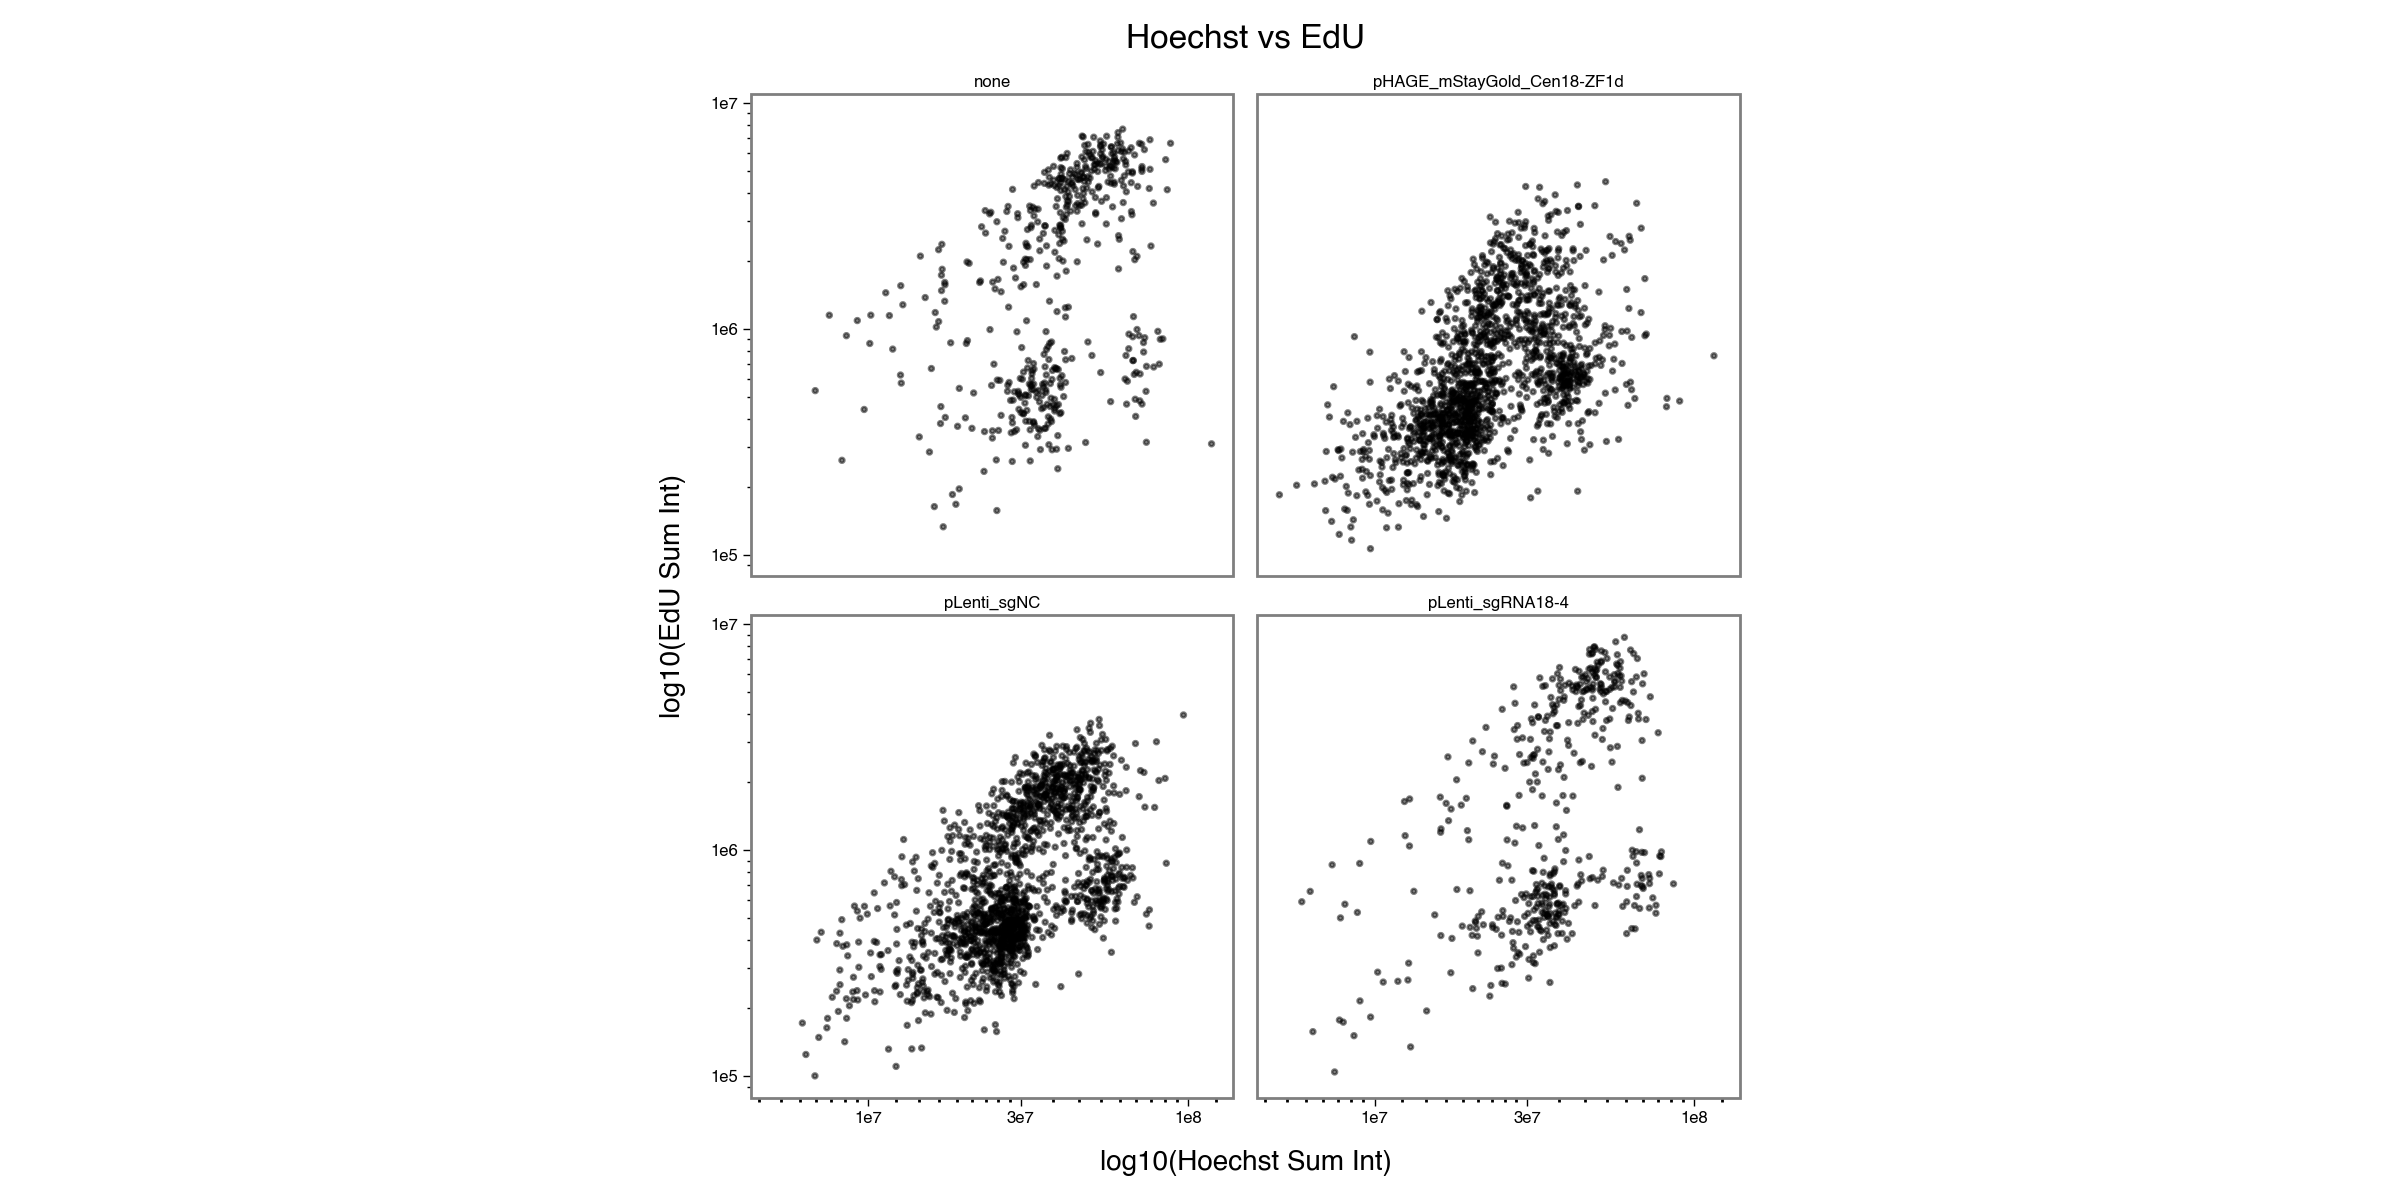

In [15]:
# Make a scatter plot of Hoechst sum intensity vs EdU sum intensity (both as log)
# for each of the experimental groups ("plasmid")

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_sum_int', 
                               y = 'ch4_sum_int')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.scale_x_log10() +
    p9.scale_y_log10() +
    p9.labs(
        title = 'Hoechst vs EdU',
        x = 'log10(Hoechst Sum Int)',
        y = 'log10(EdU Sum Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill = 'white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot